In [5]:
"""
===============================================================================
TELECOM CUSTOMER ANALYTICS PROJECT
===============================================================================

Project: Customer Churn Prediction, CLTV Analysis & Customer Segmentation

Industry: Telecommunications

Dataset:
IBM Telco Customer Churn Dataset
~7,000 Customers | Customer Demographics, Services & Churn Data

Project Objectives:
1. Analyze customer churn behavior
2. Identify key churn drivers
3. Predict customer churn using machine learning
4. Analyze Customer Lifetime Value (CLTV)
5. Segment customers using K-Means clustering
6. Estimate revenue at risk
7. Build an executive business dashboard

Machine Learning Models:
- Logistic Regression
- Random Forest
- Gradient Boosting

Analytics Techniques:
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Churn Analysis
- Customer Segmentation
- CLTV Analysis
- Profitability Analysis
- Executive Reporting

Author: Kalpesh
Date: June 2026
Python Version: 3.10+

===============================================================================
"""

print("""
╔══════════════════════════════════════════════════════════════════════════╗
║                TELECOM CUSTOMER ANALYTICS PROJECT                      ║
║      Churn Prediction | CLTV Analysis | Customer Segmentation          ║
╚══════════════════════════════════════════════════════════════════════════╝
""")

# ============================================================================
# SECTION 0: ENVIRONMENT SETUP & LIBRARY IMPORTS
# ============================================================================

# Core Data Manipulation
import pandas as pd
import numpy as np

from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Utilities
import os
import json

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproducibility
np.random.seed(42)

print(" All libraries imported successfully!")
print(
    f"Analysis started at: "
    f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
)


╔══════════════════════════════════════════════════════════════════════════╗
║                TELECOM CUSTOMER ANALYTICS PROJECT                      ║
║      Churn Prediction | CLTV Analysis | Customer Segmentation          ║
╚══════════════════════════════════════════════════════════════════════════╝

 All libraries imported successfully!
Analysis started at: 2026-06-14 13:53:22


In [7]:
# ============================================================================
# SECTION 1: DATA LOADING & BUSINESS UNDERSTANDING
# ============================================================================

print("="*80)
print("SECTION 1: DATA LOADING & BUSINESS UNDERSTANDING")
print("="*80)

print("""
Dataset:
IBM Telco Customer Churn Dataset

Business Objectives:
1. Understand customer churn behavior
2. Identify key churn drivers
3. Predict customer churn using machine learning
4. Analyze customer lifetime value
5. Segment customers for targeted retention
6. Estimate revenue at risk
7. Build an executive dashboard
""")

# ============================================================================
# UPLOAD DATASET (Google Colab)
# ============================================================================

from google.colab import files

print("\nUpload IBM Telco Dataset CSV File...")
uploaded = files.upload()

# ============================================================================
# LOAD DATASET
# ============================================================================

file_name = list(uploaded.keys())[0]

print(f"\nLoading Dataset: {file_name}")

df = pd.read_csv(file_name)

print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nFirst 5 Records:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData Loaded Successfully!")

SECTION 1: DATA LOADING & BUSINESS UNDERSTANDING

Dataset:
IBM Telco Customer Churn Dataset

Business Objectives:
1. Understand customer churn behavior
2. Identify key churn drivers
3. Predict customer churn using machine learning
4. Analyze customer lifetime value
5. Segment customers for targeted retention
6. Estimate revenue at risk
7. Build an executive dashboard


Upload IBM Telco Dataset CSV File...


Saving telco.csv to telco.csv

Loading Dataset: telco.csv

Dataset Shape: 7,043 rows × 50 columns

First 5 Records:


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.02,-118.16,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.04,-118.19,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.11,-118.23,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.94,-118.33,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.97,-118.02,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges



Columns:
['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']

Data Loaded Successfully!


SECTION 2: DATA UNDERSTANDING & EXPLORATORY ANALYSIS

 DEFINING BUSINESS QUESTIONS
--------------------------------------------------------------------------------

Our analysis will answer these critical business questions:

CHURN ANALYSIS

Q1: What is the overall customer churn rate?

Q2: Which customer groups have the highest churn?

Q3: How does churn vary by:
    - Contract Type
    - Internet Service
    - Payment Method
    - Senior Citizen Status

Q4: What are the primary reasons customers leave?

Q5: What is the revenue impact of churn?

CUSTOMER VALUE ANALYSIS

Q6: Which customers generate the highest CLTV?

Q7: How does CLTV vary across customer groups?

Q8: Which customer groups are most profitable?

CUSTOMER SEGMENTATION

Q9: Can customers be grouped into distinct segments?

Q10: Which segments require retention efforts?

Q11: Which segments contribute the most value?

CHURN PREDICTION

Q12: Can we predict customer churn using machine learning?

Q13: What are the strongest

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.02,-118.16,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.04,-118.19,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.11,-118.23,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.94,-118.33,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.97,-118.02,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges




Data Types:
Customer ID                           object
Gender                                object
Age                                    int64
Under 30                              object
Senior Citizen                        object
Married                               object
Dependents                            object
Number of Dependents                   int64
Country                               object
State                                 object
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Population                             int64
Quarter                               object
Referred a Friend                     object
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    floa

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
count,7043,7043,7043.00,7043,7043,7043,7043,7043.00,7043,7043,7043,7043.00,7043.00,7043.00,7043.00,7043,7043,7043.00,7043.00,3166,7043,7043.00,7043,7043,5517,7043.00,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043,7043,7043.00,7043.00,1869,1869
unique,7043,2,NaN,2,2,2,2,NaN,1,1,1106,NaN,NaN,NaN,NaN,1,2,NaN,NaN,5,2,NaN,2,2,3,NaN,2,2,2,2,2,2,2,2,3,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,NaN,NaN,5,20
top,3186-AJIEK,Male,NaN,No,No,No,No,NaN,United States,California,Los Angeles,NaN,NaN,NaN,NaN,Q3,No,NaN,NaN,Offer B,Yes,NaN,No,Yes,Fiber Optic,NaN,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stayed,No,NaN,NaN,Competitor,Competitor had better devices
freq,1,3555,NaN,5642,5901,3641,5416,NaN,7043,7043,293,NaN,NaN,NaN,NaN,7043,3821,NaN,NaN,824,6361,NaN,4072,5517,3035,NaN,5024,4614,4621,4999,4336,4311,4555,4745,3610,4171,3909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4720,5174,NaN,NaN,841,313
mean,NaN,NaN,46.51,NaN,NaN,NaN,NaN,0.47,NaN,NaN,NaN,93486.07,36.20,-119.76,22139.60,NaN,NaN,1.95,32.39,NaN,NaN,22.96,NaN,NaN,NaN,20.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.76,2280.38,1.96,6.86,749.10,3034.38,3.24,NaN,NaN,58.51,4400.30,NaN,NaN
std,NaN,NaN,16.75,NaN,NaN,NaN,NaN,0.96,NaN,NaN,NaN,1856.77,2.47,2.15,21152.39,NaN,NaN,3.00,24.54,NaN,NaN,15.45,NaN,NaN,NaN,20.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.09,2266.22,7.90,25.10,846.66,2865.20,1.20,NaN,NaN,21.17,1183.06,NaN,NaN
min,NaN,NaN,19.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,90001.00,32.56,-124.30,11.00,NaN,NaN,0.00,1.00,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,18.80,0.00,0.00,0.00,21.36,1.00,NaN,NaN,5.00,2003.00,NaN,NaN
25%,NaN,NaN,32.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,92101.00,33.99,-121.79,2344.00,NaN,NaN,0.00,9.00,NaN,NaN,9.21,NaN,NaN,NaN,3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,400.15,0.00,0.00,70.55,605.61,3.00,NaN,NaN,40.00,3469.00,NaN,NaN
50%,NaN,NaN,46.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,93518.00,36.21,-119.60,17554.00,NaN,NaN,0.00,29.00,NaN,NaN,22.89,NaN,NaN,NaN,17.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.35,1394.55,0.00,0.00,401.44,2108.64,3.00,NaN,NaN,61.00,4527.00,NaN,NaN
75%,NaN,NaN,60.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,95329.00,38.16,-117.97,36125.00,NaN,NaN,3.00,55.00,NaN,NaN,36.39,NaN,NaN,NaN,27.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.85,3786.60,0.00,0.00,1191.10,4801.15,4.00,NaN,NaN,75.50,5380.50,NaN,NaN




Missing Values:


,Column,Missing_Count,Missing_Percentage
Churn Reason,Churn Reason,5174,73.46
Churn Category,Churn Category,5174,73.46
Offer,Offer,3877,55.05
Internet Type,Internet Type,1526,21.67




--------------------------------------------------------------------------------
2.2: CHURN DISTRIBUTION ANALYSIS
--------------------------------------------------------------------------------

Customer Churn Distribution:

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Overall Churn Rate: 26.54%


--------------------------------------------------------------------------------
2.3: INITIAL DATA VISUALIZATIONS
--------------------------------------------------------------------------------

 Saved: 01_initial_exploration.png


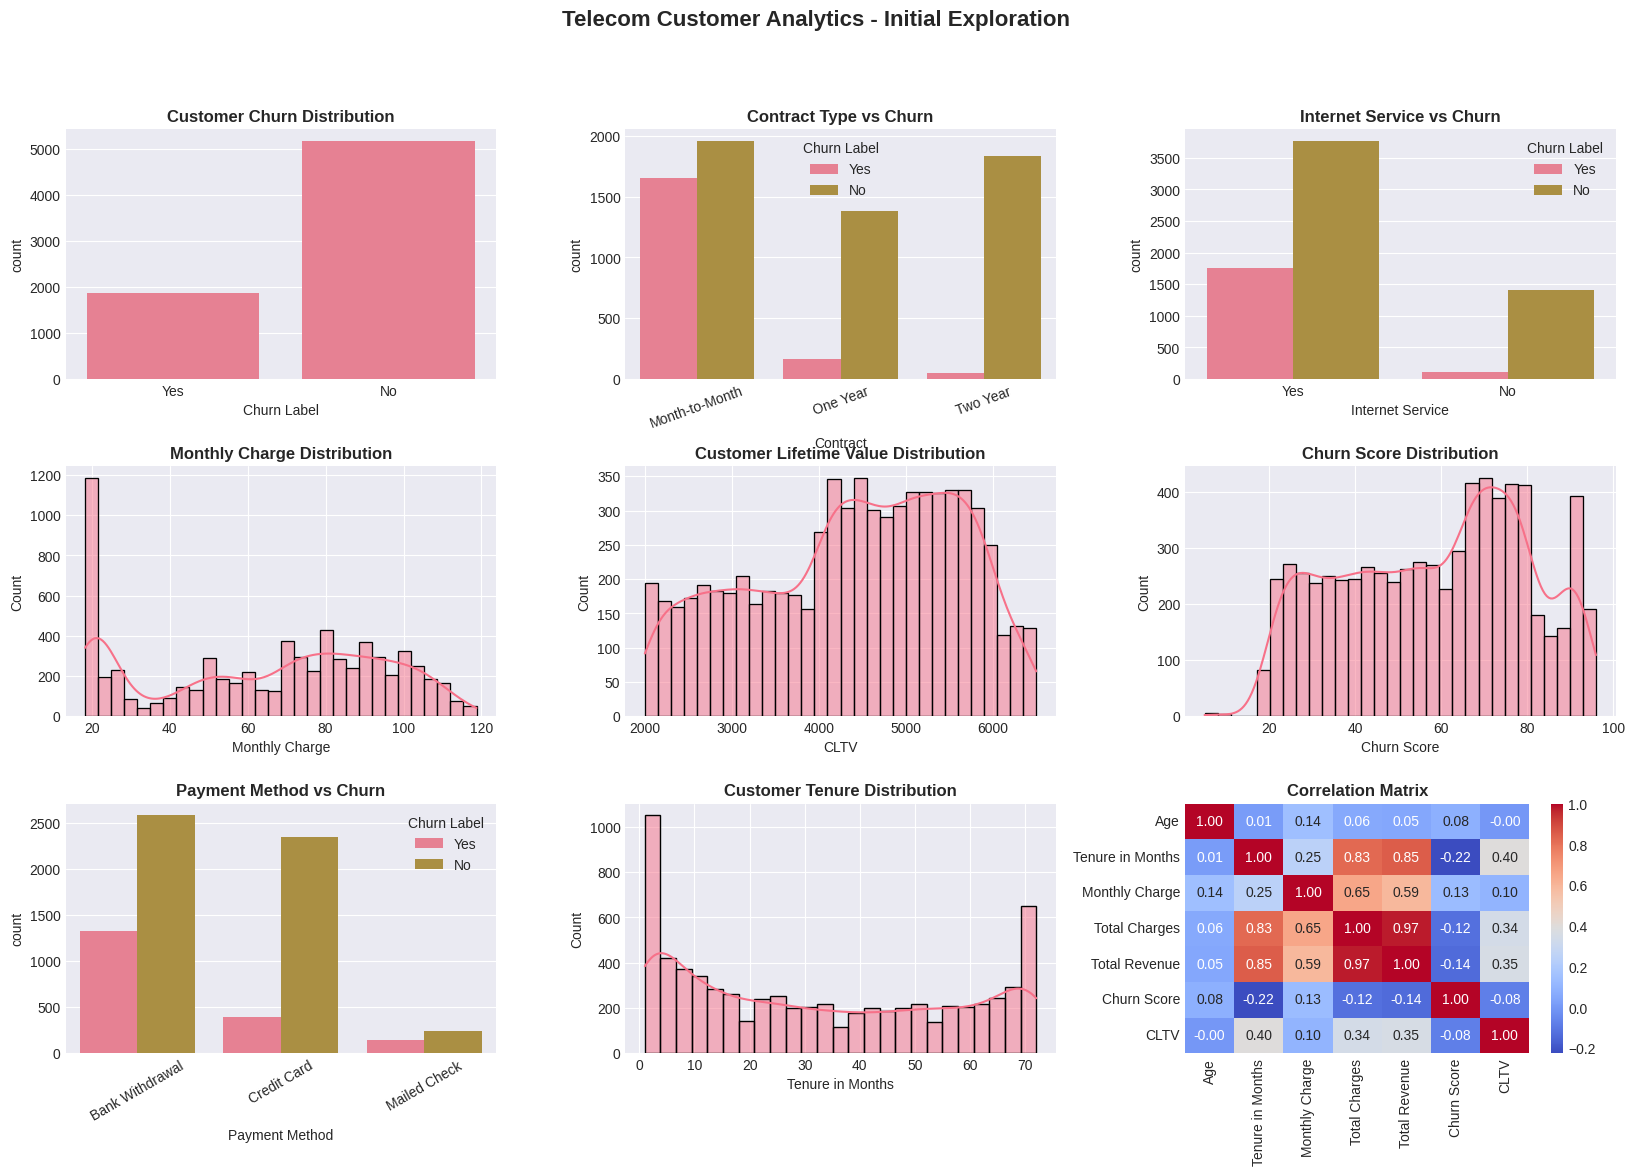


 Data Exploration Complete!


In [9]:
# ============================================================================
# SECTION 2: DATA UNDERSTANDING & EXPLORATORY ANALYSIS
# ============================================================================

print("="*80)
print("SECTION 2: DATA UNDERSTANDING & EXPLORATORY ANALYSIS")
print("="*80)

print("\n DEFINING BUSINESS QUESTIONS")
print("-"*80)

business_questions = """
Our analysis will answer these critical business questions:

CHURN ANALYSIS

Q1: What is the overall customer churn rate?

Q2: Which customer groups have the highest churn?

Q3: How does churn vary by:
    - Contract Type
    - Internet Service
    - Payment Method
    - Senior Citizen Status

Q4: What are the primary reasons customers leave?

Q5: What is the revenue impact of churn?

CUSTOMER VALUE ANALYSIS

Q6: Which customers generate the highest CLTV?

Q7: How does CLTV vary across customer groups?

Q8: Which customer groups are most profitable?

CUSTOMER SEGMENTATION

Q9: Can customers be grouped into distinct segments?

Q10: Which segments require retention efforts?

Q11: Which segments contribute the most value?

CHURN PREDICTION

Q12: Can we predict customer churn using machine learning?

Q13: What are the strongest churn predictors?

Q14: How many customers are currently at risk?

Q15: How much revenue is currently at risk?
"""

print(business_questions)

# ========================================================================
# 2.1: CUSTOMER DATA EXPLORATION
# ========================================================================

print("\n" + "-"*80)
print("2.1: CUSTOMER DATA EXPLORATION")
print("-"*80)

print("\n Customer Dataset Overview:")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

print("Available Columns:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

print("\n\nData Types:")
print(df.dtypes)

print("\n\nSummary Statistics:")
display(df.describe(include='all'))

print("\n\nMissing Values:")

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary['Missing_Count'] > 0
]

if len(missing_summary) > 0:
    display(
        missing_summary.sort_values(
            by='Missing_Count',
            ascending=False
        )
    )
else:
    print(" No missing values detected!")

# ========================================================================
# 2.2: TARGET VARIABLE ANALYSIS
# ========================================================================

print("\n\n" + "-"*80)
print("2.2: CHURN DISTRIBUTION ANALYSIS")
print("-"*80)

print("\nCustomer Churn Distribution:\n")

churn_dist = df['Churn Label'].value_counts()

print(churn_dist)

churn_rate = (
    (df['Churn Label'] == 'Yes').mean()
) * 100

print(f"\nOverall Churn Rate: {churn_rate:.2f}%")

# ========================================================================
# 2.3: INITIAL DATA VISUALIZATIONS
# ========================================================================

print("\n\n" + "-"*80)
print("2.3: INITIAL DATA VISUALIZATIONS")
print("-"*80)

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.30)

# ------------------------------------------------------------------------
# 1. Churn Distribution
# ------------------------------------------------------------------------

ax1 = fig.add_subplot(gs[0, 0])

sns.countplot(
    data=df,
    x='Churn Label',
    ax=ax1
)

ax1.set_title(
    'Customer Churn Distribution',
    fontweight='bold'
)

# ------------------------------------------------------------------------
# 2. Contract Type vs Churn
# ------------------------------------------------------------------------

ax2 = fig.add_subplot(gs[0, 1])

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn Label',
    ax=ax2
)

ax2.set_title(
    'Contract Type vs Churn',
    fontweight='bold'
)

ax2.tick_params(axis='x', rotation=20)

# ------------------------------------------------------------------------
# 3. Internet Service vs Churn
# ------------------------------------------------------------------------

ax3 = fig.add_subplot(gs[0, 2])

sns.countplot(
    data=df,
    x='Internet Service',
    hue='Churn Label',
    ax=ax3
)

ax3.set_title(
    'Internet Service vs Churn',
    fontweight='bold'
)

# ------------------------------------------------------------------------
# 4. Monthly Charge Distribution
# ------------------------------------------------------------------------

ax4 = fig.add_subplot(gs[1, 0])

sns.histplot(
    df['Monthly Charge'],
    bins=30,
    kde=True,
    ax=ax4
)

ax4.set_title(
    'Monthly Charge Distribution',
    fontweight='bold'
)

# ------------------------------------------------------------------------
# 5. CLTV Distribution
# ------------------------------------------------------------------------

ax5 = fig.add_subplot(gs[1, 1])

sns.histplot(
    df['CLTV'],
    bins=30,
    kde=True,
    ax=ax5
)

ax5.set_title(
    'Customer Lifetime Value Distribution',
    fontweight='bold'
)

# ------------------------------------------------------------------------
# 6. Churn Score Distribution
# ------------------------------------------------------------------------

ax6 = fig.add_subplot(gs[1, 2])

sns.histplot(
    df['Churn Score'],
    bins=30,
    kde=True,
    ax=ax6
)

ax6.set_title(
    'Churn Score Distribution',
    fontweight='bold'
)

# ------------------------------------------------------------------------
# 7. Payment Method vs Churn
# ------------------------------------------------------------------------

ax7 = fig.add_subplot(gs[2, 0])

sns.countplot(
    data=df,
    x='Payment Method',
    hue='Churn Label',
    ax=ax7
)

ax7.set_title(
    'Payment Method vs Churn',
    fontweight='bold'
)

ax7.tick_params(axis='x', rotation=30)

# ------------------------------------------------------------------------
# 8. Tenure Distribution
# ------------------------------------------------------------------------

ax8 = fig.add_subplot(gs[2, 1])

sns.histplot(
    df['Tenure in Months'],
    bins=25,
    kde=True,
    ax=ax8
)

ax8.set_title(
    'Customer Tenure Distribution',
    fontweight='bold'
)

# ------------------------------------------------------------------------
# 9. Correlation Heatmap
# ------------------------------------------------------------------------

ax9 = fig.add_subplot(gs[2, 2])

corr_cols = [
    'Age',
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Total Revenue',
    'Churn Score',
    'CLTV'
]

corr_matrix = df[corr_cols].corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=ax9
)

ax9.set_title(
    'Correlation Matrix',
    fontweight='bold'
)

plt.suptitle(
    'Telecom Customer Analytics - Initial Exploration',
    fontsize=16,
    fontweight='bold'
)

plt.savefig(
    '01_initial_exploration.png',
    dpi=300,
    bbox_inches='tight'
)

print("\n Saved: 01_initial_exploration.png")

plt.show()

print("\n Data Exploration Complete!")

SECTION 3: DATA CLEANING & FEATURE ENGINEERING

--------------------------------------------------------------------------------
3.1: MISSING VALUE ANALYSIS
--------------------------------------------------------------------------------


,Missing_Count,Missing_Percentage
Churn Reason,5174,73.46
Churn Category,5174,73.46
Offer,3877,55.05
Internet Type,1526,21.67



--------------------------------------------------------------------------------
3.2: HANDLING MISSING VALUES
--------------------------------------------------------------------------------
 Missing values handled

--------------------------------------------------------------------------------
3.3: FEATURE ENGINEERING
--------------------------------------------------------------------------------
 New Features Created:

1. Revenue Segment
2. Tenure Group
3. CLTV Segment
4. Churn_Flag


--------------------------------------------------------------------------------
3.4: FEATURE SUMMARY
--------------------------------------------------------------------------------

Revenue Segments:
Revenue Segment
Medium Revenue     1766
Low Revenue        1762
Premium Revenue    1758
High Revenue       1757
Name: count, dtype: int64

Tenure Groups:
Tenure Group
Loyal          2239
New            2186
Established    1594
Developing     1024
Name: count, dtype: int64

CLTV Segments:
CLTV Segment
L

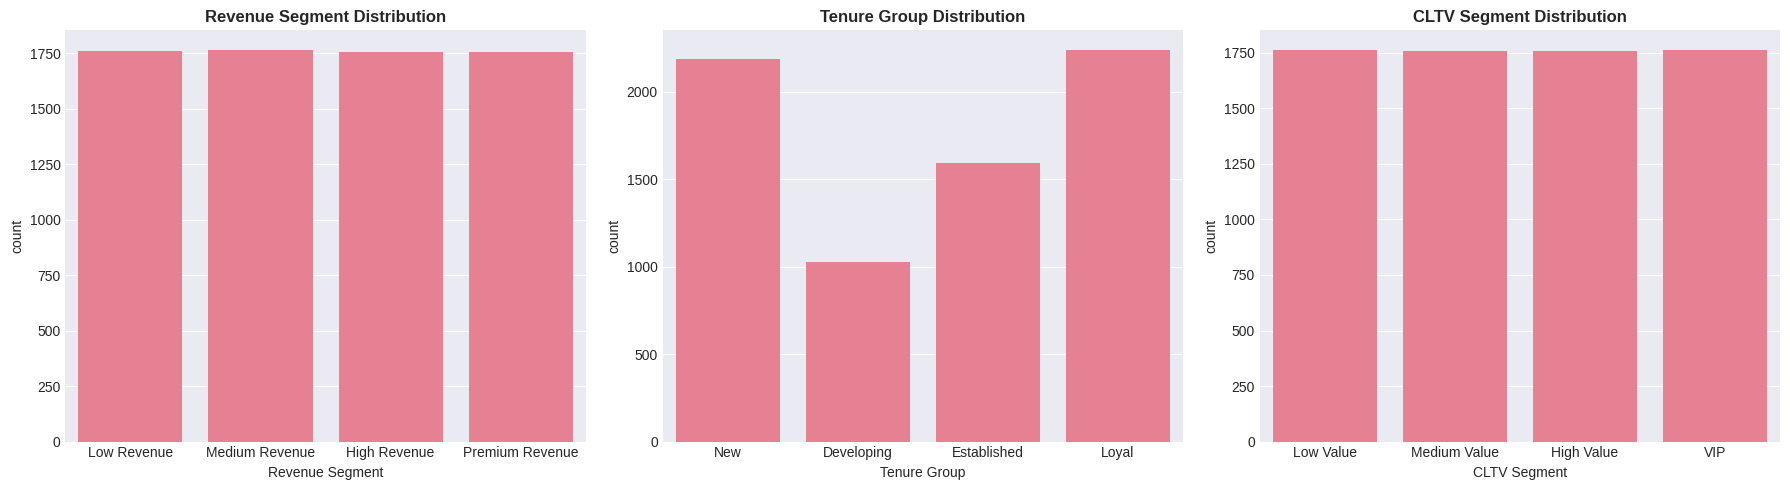


 Data Cleaning & Feature Engineering Complete!


In [10]:
# ============================================================================
# SECTION 3: DATA CLEANING & FEATURE ENGINEERING
# ============================================================================

print("="*80)
print("SECTION 3: DATA CLEANING & FEATURE ENGINEERING")
print("="*80)

# Create working copy
df_clean = df.copy()

# ========================================================================
# 3.1: MISSING VALUE ANALYSIS
# ========================================================================

print("\n" + "-"*80)
print("3.1: MISSING VALUE ANALYSIS")
print("-"*80)

missing_values = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage":
        (df_clean.isnull().sum()/len(df_clean)*100).round(2)
})

missing_values = missing_values[
    missing_values["Missing_Count"] > 0
]

if len(missing_values) > 0:
    display(
        missing_values.sort_values(
            "Missing_Count",
            ascending=False
        )
    )
else:
    print(" No Missing Values Found")

# ========================================================================
# 3.2: HANDLE MISSING VALUES
# ========================================================================

print("\n" + "-"*80)
print("3.2: HANDLING MISSING VALUES")
print("-"*80)

# Offer column contains NaN
if 'Offer' in df_clean.columns:
    df_clean['Offer'] = df_clean['Offer'].fillna('No Offer')

# Churn Reason only exists for churned customers
if 'Churn Reason' in df_clean.columns:
    df_clean['Churn Reason'] = df_clean['Churn Reason'].fillna('Not Churned')

if 'Churn Category' in df_clean.columns:
    df_clean['Churn Category'] = df_clean['Churn Category'].fillna('Not Churned')

print(" Missing values handled")

# ========================================================================
# 3.3: FEATURE ENGINEERING
# ========================================================================

print("\n" + "-"*80)
print("3.3: FEATURE ENGINEERING")
print("-"*80)

# Monthly Revenue Category

df_clean['Revenue Segment'] = pd.qcut(
    df_clean['Monthly Charge'],
    q=4,
    labels=[
        'Low Revenue',
        'Medium Revenue',
        'High Revenue',
        'Premium Revenue'
    ]
)

# Customer Lifetime Group

df_clean['Tenure Group'] = pd.cut(
    df_clean['Tenure in Months'],
    bins=[0,12,24,48,72],
    labels=[
        'New',
        'Developing',
        'Established',
        'Loyal'
    ]
)

# CLTV Segment

df_clean['CLTV Segment'] = pd.qcut(
    df_clean['CLTV'],
    q=4,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'VIP'
    ]
)

# Churn Target Variable

df_clean['Churn_Flag'] = np.where(
    df_clean['Churn Label'] == 'Yes',
    1,
    0
)

print(" New Features Created:")
print("""
1. Revenue Segment
2. Tenure Group
3. CLTV Segment
4. Churn_Flag
""")

# ========================================================================
# 3.4: FEATURE SUMMARY
# ========================================================================

print("\n" + "-"*80)
print("3.4: FEATURE SUMMARY")
print("-"*80)

print("\nRevenue Segments:")
print(df_clean['Revenue Segment'].value_counts())

print("\nTenure Groups:")
print(df_clean['Tenure Group'].value_counts())

print("\nCLTV Segments:")
print(df_clean['CLTV Segment'].value_counts())

# ========================================================================
# 3.5: FEATURE VISUALIZATION
# ========================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

sns.countplot(
    data=df_clean,
    x='Revenue Segment',
    ax=axes[0]
)

axes[0].set_title(
    'Revenue Segment Distribution',
    fontweight='bold'
)

sns.countplot(
    data=df_clean,
    x='Tenure Group',
    ax=axes[1]
)

axes[1].set_title(
    'Tenure Group Distribution',
    fontweight='bold'
)

sns.countplot(
    data=df_clean,
    x='CLTV Segment',
    ax=axes[2]
)

axes[2].set_title(
    'CLTV Segment Distribution',
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '02_feature_engineering.png',
    dpi=300,
    bbox_inches='tight'
)

print("\n Saved: 02_feature_engineering.png")

plt.show()

print("\n Data Cleaning & Feature Engineering Complete!")

SECTION 4: CHURN ANALYSIS & BUSINESS INSIGHTS

Business Goal:
Understand why customers leave and identify
high-risk customer groups.


--------------------------------------------------------------------------------
4.1: OVERALL CHURN ANALYSIS
--------------------------------------------------------------------------------
Total Customers : 7,043
Active Customers : 5,174
Churned Customers : 1,869
Overall Churn Rate : 26.54%

--------------------------------------------------------------------------------
4.2: CHURN BY CONTRACT TYPE
--------------------------------------------------------------------------------


Churn Label,No,Yes
Contract,,
Month-to-Month,54.16,45.84
One Year,89.29,10.71
Two Year,97.45,2.55



--------------------------------------------------------------------------------
4.3: CHURN BY INTERNET SERVICE
--------------------------------------------------------------------------------


Churn Label,No,Yes
Internet Type,,
Cable,74.34,25.66
DSL,81.42,18.58
Fiber Optic,59.28,40.72



--------------------------------------------------------------------------------
4.4: CHURN BY PAYMENT METHOD
--------------------------------------------------------------------------------


Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,66.00,34.00
Credit Card,85.52,14.48
Mailed Check,63.12,36.88



--------------------------------------------------------------------------------
4.5: CUSTOMER CHURN REASONS
--------------------------------------------------------------------------------
Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64

--------------------------------------------------------------------------------
4.6: REVENUE AT RISK
--------------------------------------------------------------------------------
Revenue Lost Due To Churn : $3,684,459.82

 Saved: 03_churn_analysis.png


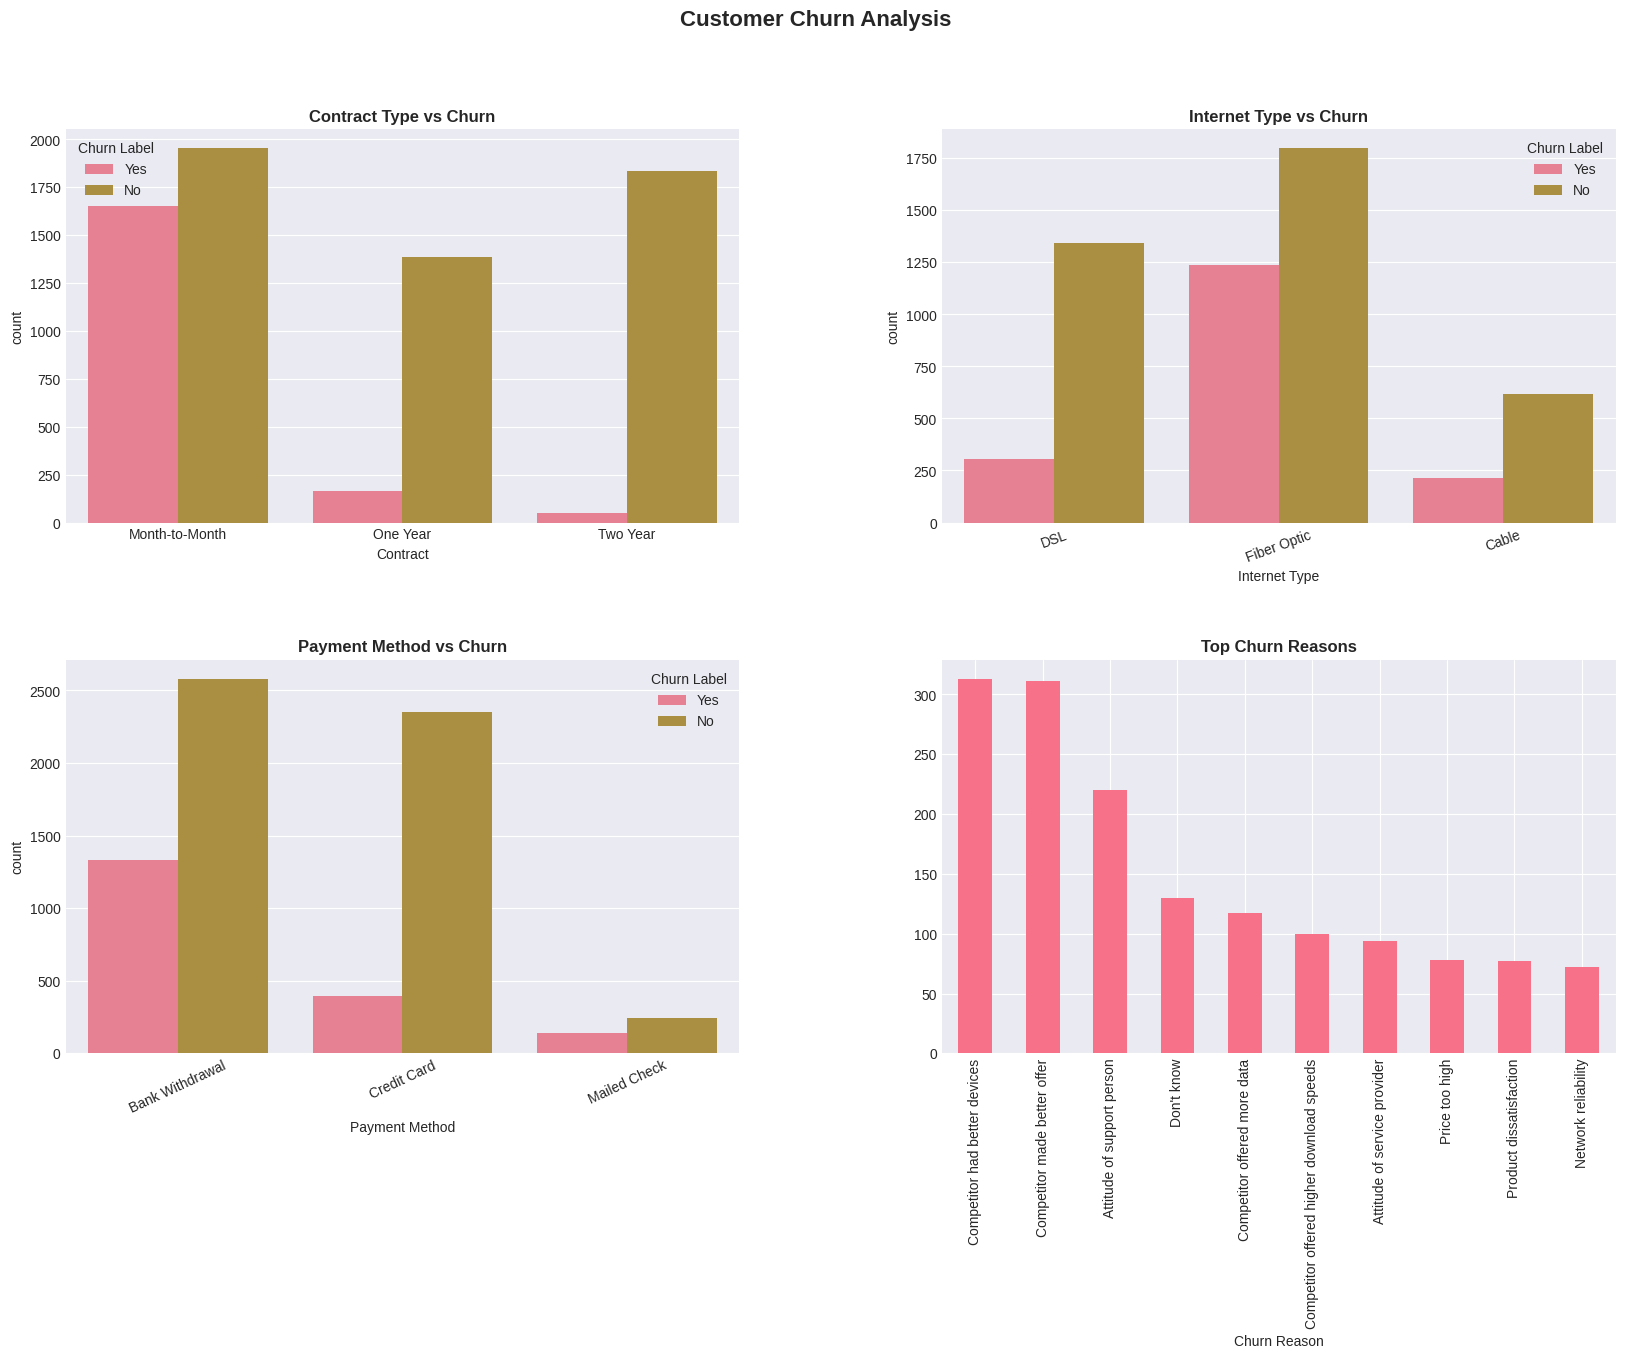


 Churn Analysis Complete!


In [11]:
# ============================================================================
# SECTION 4: CHURN ANALYSIS & BUSINESS INSIGHTS
# ============================================================================

print("="*80)
print("SECTION 4: CHURN ANALYSIS & BUSINESS INSIGHTS")
print("="*80)

print("""
Business Goal:
Understand why customers leave and identify
high-risk customer groups.
""")

# ========================================================================
# 4.1 OVERALL CHURN ANALYSIS
# ========================================================================

print("\n" + "-"*80)
print("4.1: OVERALL CHURN ANALYSIS")
print("-"*80)

total_customers = len(df_clean)

churned_customers = (
    df_clean['Churn Label'] == 'Yes'
).sum()

active_customers = (
    df_clean['Churn Label'] == 'No'
).sum()

churn_rate = (
    churned_customers /
    total_customers
) * 100

print(f"Total Customers : {total_customers:,}")
print(f"Active Customers : {active_customers:,}")
print(f"Churned Customers : {churned_customers:,}")
print(f"Overall Churn Rate : {churn_rate:.2f}%")

# ========================================================================
# 4.2 CHURN BY CONTRACT
# ========================================================================

print("\n" + "-"*80)
print("4.2: CHURN BY CONTRACT TYPE")
print("-"*80)

contract_churn = pd.crosstab(
    df_clean['Contract'],
    df_clean['Churn Label'],
    normalize='index'
) * 100

display(contract_churn.round(2))

# ========================================================================
# 4.3 CHURN BY INTERNET SERVICE
# ========================================================================

print("\n" + "-"*80)
print("4.3: CHURN BY INTERNET SERVICE")
print("-"*80)

internet_churn = pd.crosstab(
    df_clean['Internet Type'],
    df_clean['Churn Label'],
    normalize='index'
) * 100

display(internet_churn.round(2))

# ========================================================================
# 4.4 CHURN BY PAYMENT METHOD
# ========================================================================

print("\n" + "-"*80)
print("4.4: CHURN BY PAYMENT METHOD")
print("-"*80)

payment_churn = pd.crosstab(
    df_clean['Payment Method'],
    df_clean['Churn Label'],
    normalize='index'
) * 100

display(payment_churn.round(2))

# ========================================================================
# 4.5 CHURN REASONS
# ========================================================================

print("\n" + "-"*80)
print("4.5: CUSTOMER CHURN REASONS")
print("-"*80)

top_reasons = (
    df_clean[
        df_clean['Churn Label'] == 'Yes'
    ]['Churn Reason']
    .value_counts()
    .head(10)
)

print(top_reasons)

# ========================================================================
# 4.6 REVENUE AT RISK
# ========================================================================

print("\n" + "-"*80)
print("4.6: REVENUE AT RISK")
print("-"*80)

revenue_lost = df_clean[
    df_clean['Churn Label'] == 'Yes'
]['Total Revenue'].sum()

print(f"Revenue Lost Due To Churn : ${revenue_lost:,.2f}")

# ========================================================================
# 4.7 VISUALIZATIONS
# ========================================================================

fig = plt.figure(
    figsize=(20,12)
)

gs = GridSpec(
    2,
    2,
    figure=fig,
    hspace=0.35,
    wspace=0.30
)

# Contract

ax1 = fig.add_subplot(gs[0,0])

sns.countplot(
    data=df_clean,
    x='Contract',
    hue='Churn Label',
    ax=ax1
)

ax1.set_title(
    'Contract Type vs Churn',
    fontweight='bold'
)

# Internet Type

ax2 = fig.add_subplot(gs[0,1])

sns.countplot(
    data=df_clean,
    x='Internet Type',
    hue='Churn Label',
    ax=ax2
)

ax2.set_title(
    'Internet Type vs Churn',
    fontweight='bold'
)

ax2.tick_params(
    axis='x',
    rotation=20
)

# Payment Method

ax3 = fig.add_subplot(gs[1,0])

sns.countplot(
    data=df_clean,
    x='Payment Method',
    hue='Churn Label',
    ax=ax3
)

ax3.set_title(
    'Payment Method vs Churn',
    fontweight='bold'
)

ax3.tick_params(
    axis='x',
    rotation=25
)

# Churn Reasons

ax4 = fig.add_subplot(gs[1,1])

top_reasons.plot(
    kind='bar',
    ax=ax4
)

ax4.set_title(
    'Top Churn Reasons',
    fontweight='bold'
)

plt.suptitle(
    'Customer Churn Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.savefig(
    '03_churn_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

print("\n Saved: 03_churn_analysis.png")

plt.show()

print("\n Churn Analysis Complete!")

SECTION 5: CHURN PREDICTION USING MACHINE LEARNING

Creating Target Variable...
Target
0    5174
1    1869
Name: count, dtype: int64

Feature Matrix Shape : (7043, 17)
Target Shape : (7043,)

Training Rows : 5634
Testing Rows : 1409

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

MODEL PERFORMANCE


,Model,Accuracy,ROC_AUC
2,Gradient Boosting,0.83,0.89
0,Logistic Regression,0.82,0.87
1,Random Forest,0.81,0.87



Top Churn Predictors:


,Feature,Importance
2,Monthly Charge,0.13
4,Total Revenue,0.13
3,Total Charges,0.12
1,Tenure in Months,0.12
0,Age,0.11
5,CLTV,0.10
13,Contract_Two Year,0.06
12,Contract_One Year,0.04
11,Internet Type_Fiber Optic,0.04
8,Dependents_Yes,0.03


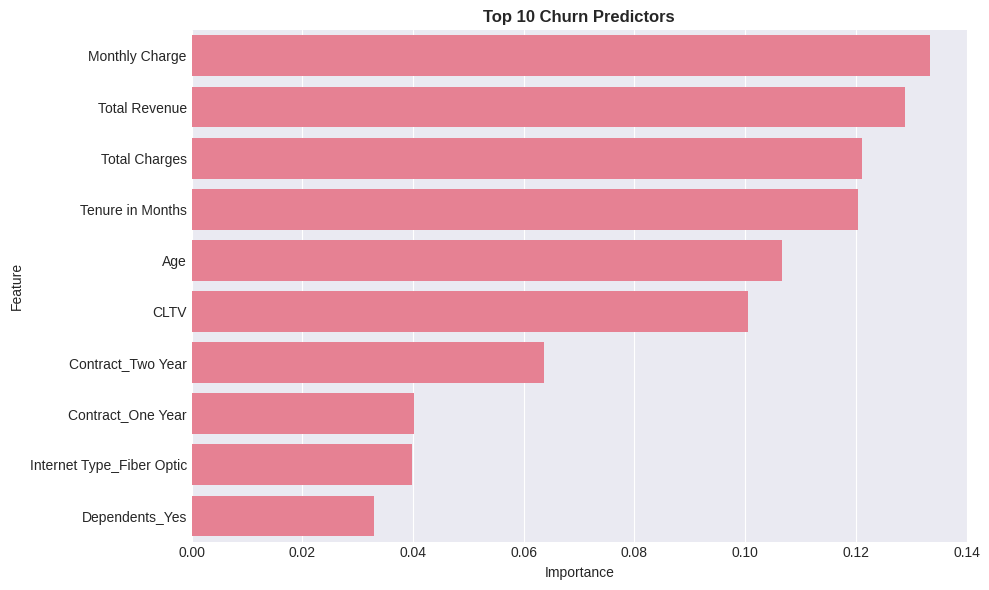


Machine Learning Analysis Complete!


In [13]:
# ============================================================================
# SECTION 5: CHURN PREDICTION USING MACHINE LEARNING
# ============================================================================

print("="*80)
print("SECTION 5: CHURN PREDICTION USING MACHINE LEARNING")
print("="*80)

# ========================================================================
# 5.1 TARGET VARIABLE CREATION
# ========================================================================

print("\nCreating Target Variable...")

df_ml = df_clean.copy()

df_ml['Target'] = df_ml['Churn Label'].map({
    'Yes':1,
    'No':0
})

print(df_ml['Target'].value_counts())

# ========================================================================
# 5.2 FEATURE SELECTION
# ========================================================================

features = [
    'Age',
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Total Revenue',
    'CLTV'
]

categorical_features = [
    'Gender',
    'Married',
    'Dependents',
    'Internet Service',
    'Internet Type',
    'Contract',
    'Paperless Billing',
    'Payment Method'
]

# ========================================================================
# 5.3 PREPARE MODEL DATA
# ========================================================================

model_df = df_ml[
    features +
    categorical_features +
    ['Target']
].copy()

model_df = pd.get_dummies(
    model_df,
    columns=categorical_features,
    drop_first=True
)

X = model_df.drop('Target', axis=1)

y = model_df['Target']

print(f"\nFeature Matrix Shape : {X.shape}")
print(f"Target Shape : {y.shape}")

# ========================================================================
# 5.4 TRAIN TEST SPLIT
# ========================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\nTraining Rows : {X_train.shape[0]}")
print(f"Testing Rows : {X_test.shape[0]}")

# ========================================================================
# 5.5 SCALING
# ========================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========================================================================
# 5.6 LOGISTIC REGRESSION
# ========================================================================

print("\nTraining Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(X_test_scaled)

lr_prob = lr_model.predict_proba(
    X_test_scaled
)[:,1]

# ========================================================================
# 5.7 RANDOM FOREST
# ========================================================================

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

# ========================================================================
# 5.8 GRADIENT BOOSTING
# ========================================================================

print("Training Gradient Boosting...")

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(X_test)

gb_prob = gb_model.predict_proba(
    X_test
)[:,1]

# ========================================================================
# 5.9 MODEL COMPARISON
# ========================================================================

results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    'ROC_AUC':[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

print("\nMODEL PERFORMANCE")
display(
    results.sort_values(
        'ROC_AUC',
        ascending=False
    )
)

best_model = rf_model

# ========================================================================
# 5.10 FEATURE IMPORTANCE
# ========================================================================

feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

print("\nTop Churn Predictors:")
display(
    feature_importance.head(15)
)

# ========================================================================
# 5.11 VISUALIZATION
# ========================================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Churn Predictors',
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '04_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nMachine Learning Analysis Complete!")

SECTION 6: CUSTOMER SEGMENTATION

Business Goal:
Identify distinct customer groups
for retention and marketing strategies.

Segmentation Dataset Ready
Rows : 7043
Columns : 5

Calculating Optimal Clusters...


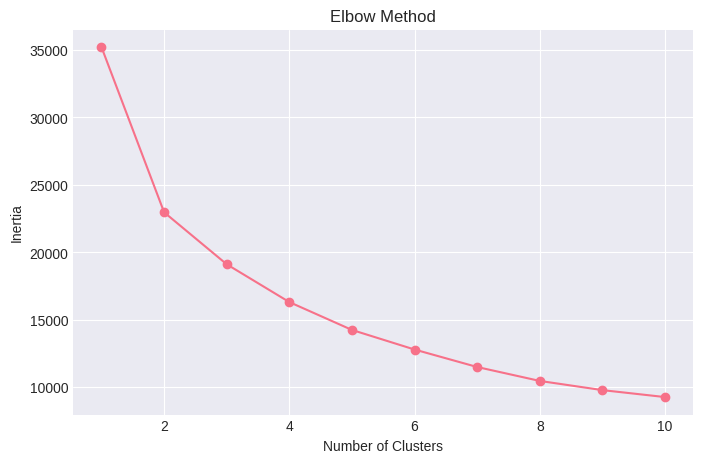


Optimal Clusters Selected : 4

Cluster Summary:


,Age,Tenure in Months,Monthly Charge,Total Revenue,CLTV
Cluster,,,,,
0,46.68,60.25,94.01,7268.44,5127.55
1,36.32,13.04,46.32,874.52,3878.95
2,61.29,18.17,78.22,1866.98,3899.99
3,44.17,54.11,35.82,2932.71,5220.44



Cluster Distribution:
Cluster
0    1751
1    2404
2    1809
3    1079
Name: count, dtype: int64

Churn Rate By Cluster:
Cluster
0   14.68
1   29.33
2   47.48
3    4.45
Name: Churn Label, dtype: float64

Average CLTV By Cluster:
Cluster
0   5127.55
1   3878.95
2   3899.99
3   5220.44
Name: CLTV, dtype: float64

Saved: 05_customer_segmentation.png


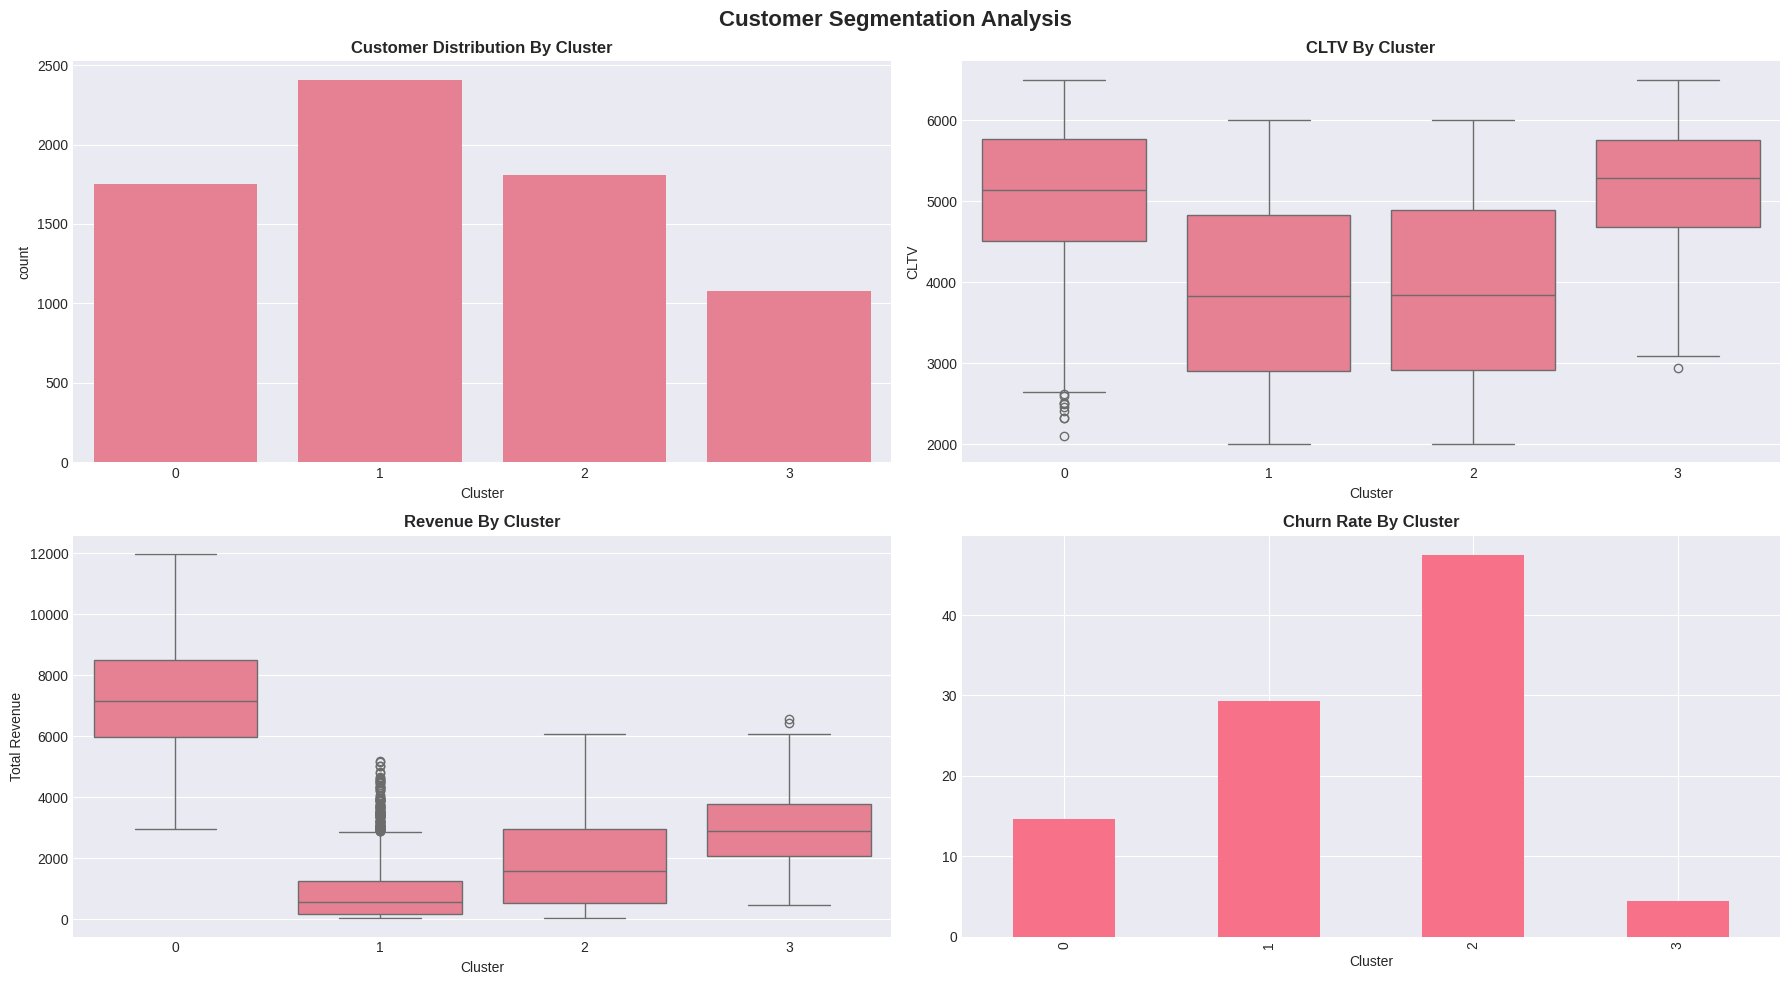


Top 10% High Value Customers
Count : 705
Average CLTV : $6,124.37
Average Revenue : $5,191.92

Customer Segmentation Complete!


In [14]:
# ============================================================================
# SECTION 6: CUSTOMER SEGMENTATION (K-MEANS CLUSTERING)
# ============================================================================

print("="*80)
print("SECTION 6: CUSTOMER SEGMENTATION")
print("="*80)

print("""
Business Goal:
Identify distinct customer groups
for retention and marketing strategies.
""")

# ========================================================================
# 6.1 SEGMENTATION DATA PREPARATION
# ========================================================================

segmentation_df = df_clean.copy()

cluster_features = [
    'Age',
    'Tenure in Months',
    'Monthly Charge',
    'Total Revenue',
    'CLTV'
]

cluster_data = segmentation_df[
    cluster_features
].copy()

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_data
)

print("Segmentation Dataset Ready")
print(f"Rows : {cluster_data.shape[0]}")
print(f"Columns : {cluster_data.shape[1]}")

# ========================================================================
# 6.2 ELBOW METHOD
# ========================================================================

print("\nCalculating Optimal Clusters...")

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(cluster_scaled)

    inertia.append(
        model.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title(
    'Elbow Method'
)

plt.xlabel(
    'Number of Clusters'
)

plt.ylabel(
    'Inertia'
)

plt.grid(True)

plt.show()

# ========================================================================
# 6.3 FINAL KMEANS MODEL
# ========================================================================

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

segmentation_df['Cluster'] = (
    kmeans.fit_predict(
        cluster_scaled
    )
)

print(f"\nOptimal Clusters Selected : {optimal_k}")

# ========================================================================
# 6.4 CLUSTER SUMMARY
# ========================================================================

cluster_summary = (
    segmentation_df
    .groupby('Cluster')
    .agg({
        'Age':'mean',
        'Tenure in Months':'mean',
        'Monthly Charge':'mean',
        'Total Revenue':'mean',
        'CLTV':'mean'
    })
    .round(2)
)

print("\nCluster Summary:")
display(cluster_summary)

# ========================================================================
# 6.5 CLUSTER SIZE
# ========================================================================

cluster_size = (
    segmentation_df['Cluster']
    .value_counts()
    .sort_index()
)

print("\nCluster Distribution:")
print(cluster_size)

# ========================================================================
# 6.6 CHURN RATE BY CLUSTER
# ========================================================================

cluster_churn = (
    segmentation_df
    .groupby('Cluster')['Churn Label']
    .apply(
        lambda x:
        (x=='Yes').mean()*100
    )
    .round(2)
)

print("\nChurn Rate By Cluster:")
print(cluster_churn)

# ========================================================================
# 6.7 CLTV BY CLUSTER
# ========================================================================

cluster_cltv = (
    segmentation_df
    .groupby('Cluster')['CLTV']
    .mean()
    .round(2)
)

print("\nAverage CLTV By Cluster:")
print(cluster_cltv)

# ========================================================================
# 6.8 VISUALIZATION
# ========================================================================

fig = plt.figure(
    figsize=(18,10)
)

gs = GridSpec(
    2,
    2,
    figure=fig
)

# Cluster Count

ax1 = fig.add_subplot(gs[0,0])

sns.countplot(
    data=segmentation_df,
    x='Cluster',
    ax=ax1
)

ax1.set_title(
    'Customer Distribution By Cluster',
    fontweight='bold'
)

# CLTV

ax2 = fig.add_subplot(gs[0,1])

sns.boxplot(
    data=segmentation_df,
    x='Cluster',
    y='CLTV',
    ax=ax2
)

ax2.set_title(
    'CLTV By Cluster',
    fontweight='bold'
)

# Revenue

ax3 = fig.add_subplot(gs[1,0])

sns.boxplot(
    data=segmentation_df,
    x='Cluster',
    y='Total Revenue',
    ax=ax3
)

ax3.set_title(
    'Revenue By Cluster',
    fontweight='bold'
)

# Churn

ax4 = fig.add_subplot(gs[1,1])

cluster_churn.plot(
    kind='bar',
    ax=ax4
)

ax4.set_title(
    'Churn Rate By Cluster',
    fontweight='bold'
)

plt.suptitle(
    'Customer Segmentation Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '05_customer_segmentation.png',
    dpi=300,
    bbox_inches='tight'
)

print(
    "\nSaved: 05_customer_segmentation.png"
)

plt.show()

# ========================================================================
# 6.9 HIGH VALUE CUSTOMERS
# ========================================================================

high_value_customers = segmentation_df[
    segmentation_df['CLTV']
    >
    segmentation_df['CLTV'].quantile(0.90)
]

print("\nTop 10% High Value Customers")

print(
    f"Count : {len(high_value_customers)}"
)

print(
    f"Average CLTV : ${high_value_customers['CLTV'].mean():,.2f}"
)

print(
    f"Average Revenue : ${high_value_customers['Total Revenue'].mean():,.2f}"
)

print("\nCustomer Segmentation Complete!")

SECTION 7: EXECUTIVE DASHBOARD & BUSINESS REPORT

--------------------------------------------------------------------------------
7.1: KEY PERFORMANCE INDICATORS
--------------------------------------------------------------------------------
Total Customers       : 7,043
Active Customers      : 5,174
Churned Customers     : 1,869
Churn Rate            : 26.54%
Average CLTV          : $4,400.30
Average Revenue       : $3,034.38
Total Revenue         : $21,371,131.69

--------------------------------------------------------------------------------
7.2: REVENUE AT RISK
--------------------------------------------------------------------------------
Revenue At Risk : $3,684,459.82

--------------------------------------------------------------------------------
7.3: TOP CHURN DRIVERS
--------------------------------------------------------------------------------


,Feature,Importance
2,Monthly Charge,0.13
4,Total Revenue,0.13
3,Total Charges,0.12
1,Tenure in Months,0.12
0,Age,0.11
5,CLTV,0.10
13,Contract_Two Year,0.06
12,Contract_One Year,0.04
11,Internet Type_Fiber Optic,0.04
8,Dependents_Yes,0.03



Saved : 06_EXECUTIVE_DASHBOARD.png


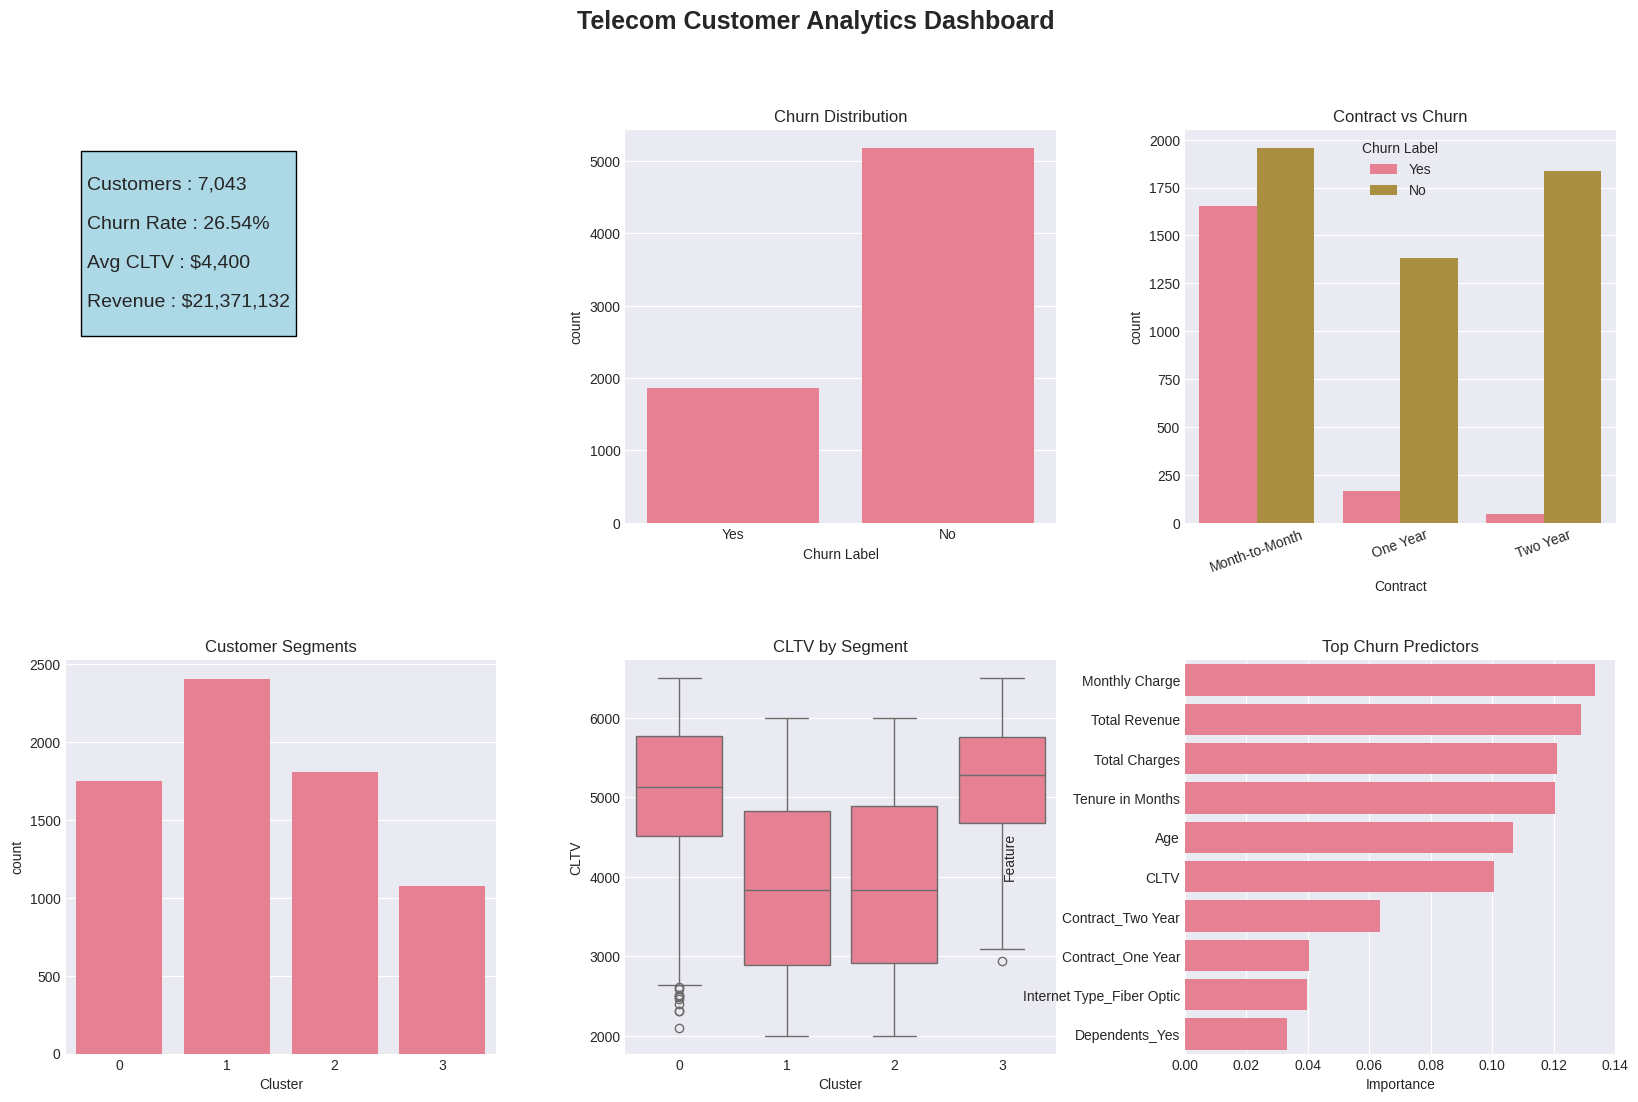


--------------------------------------------------------------------------------
BUSINESS RECOMMENDATIONS
--------------------------------------------------------------------------------


1. Focus retention efforts on Month-to-Month customers.

2. Target high churn-risk clusters with loyalty offers.

3. Improve customer support for high-value customers.

4. Create personalized retention campaigns.

5. Monitor customers with declining tenure
   and increasing monthly charges.

6. Prioritize customers with high CLTV
   before they churn.



Project Complete!


In [15]:
# ============================================================================
# SECTION 7: EXECUTIVE DASHBOARD & BUSINESS REPORT
# ============================================================================

print("="*80)
print("SECTION 7: EXECUTIVE DASHBOARD & BUSINESS REPORT")
print("="*80)

# ========================================================================
# 7.1 KPI SUMMARY
# ========================================================================

print("\n" + "-"*80)
print("7.1: KEY PERFORMANCE INDICATORS")
print("-"*80)

total_customers = len(df_clean)

active_customers = (
    df_clean['Churn Label'] == 'No'
).sum()

churned_customers = (
    df_clean['Churn Label'] == 'Yes'
).sum()

churn_rate = (
    churned_customers /
    total_customers
) * 100

avg_cltv = (
    df_clean['CLTV']
    .mean()
)

avg_revenue = (
    df_clean['Total Revenue']
    .mean()
)

total_revenue = (
    df_clean['Total Revenue']
    .sum()
)

print(f"Total Customers       : {total_customers:,}")
print(f"Active Customers      : {active_customers:,}")
print(f"Churned Customers     : {churned_customers:,}")
print(f"Churn Rate            : {churn_rate:.2f}%")
print(f"Average CLTV          : ${avg_cltv:,.2f}")
print(f"Average Revenue       : ${avg_revenue:,.2f}")
print(f"Total Revenue         : ${total_revenue:,.2f}")

# ========================================================================
# 7.2 REVENUE AT RISK
# ========================================================================

print("\n" + "-"*80)
print("7.2: REVENUE AT RISK")
print("-"*80)

revenue_at_risk = df_clean[
    df_clean['Churn Label']=='Yes'
]['Total Revenue'].sum()

print(
    f"Revenue At Risk : ${revenue_at_risk:,.2f}"
)

# ========================================================================
# 7.3 TOP CHURN DRIVERS
# ========================================================================

print("\n" + "-"*80)
print("7.3: TOP CHURN DRIVERS")
print("-"*80)

display(
    feature_importance
    .head(10)
)

# ========================================================================
# 7.4 FINAL DASHBOARD
# ========================================================================

fig = plt.figure(
    figsize=(20,12)
)

gs = GridSpec(
    2,
    3,
    figure=fig,
    hspace=0.35,
    wspace=0.30
)

# KPI

ax1 = fig.add_subplot(gs[0,0])

ax1.axis('off')

kpi_text = f"""
Customers : {total_customers:,}

Churn Rate : {churn_rate:.2f}%

Avg CLTV : ${avg_cltv:,.0f}

Revenue : ${total_revenue:,.0f}
"""

ax1.text(
    0.05,
    0.5,
    kpi_text,
    fontsize=14,
    bbox=dict(
        facecolor='lightblue'
    )
)

# Churn Distribution

ax2 = fig.add_subplot(gs[0,1])

sns.countplot(
    data=df_clean,
    x='Churn Label',
    ax=ax2
)

ax2.set_title(
    'Churn Distribution'
)

# Contract

ax3 = fig.add_subplot(gs[0,2])

sns.countplot(
    data=df_clean,
    x='Contract',
    hue='Churn Label',
    ax=ax3
)

ax3.set_title(
    'Contract vs Churn'
)

ax3.tick_params(
    axis='x',
    rotation=20
)

# Cluster Count

ax4 = fig.add_subplot(gs[1,0])

sns.countplot(
    data=segmentation_df,
    x='Cluster',
    ax=ax4
)

ax4.set_title(
    'Customer Segments'
)

# CLTV

ax5 = fig.add_subplot(gs[1,1])

sns.boxplot(
    data=segmentation_df,
    x='Cluster',
    y='CLTV',
    ax=ax5
)

ax5.set_title(
    'CLTV by Segment'
)

# Feature Importance

ax6 = fig.add_subplot(gs[1,2])

top10 = (
    feature_importance
    .head(10)
)

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature',
    ax=ax6
)

ax6.set_title(
    'Top Churn Predictors'
)

plt.suptitle(
    'Telecom Customer Analytics Dashboard',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '06_EXECUTIVE_DASHBOARD.png',
    dpi=300,
    bbox_inches='tight'
)

print(
    "\nSaved : 06_EXECUTIVE_DASHBOARD.png"
)

plt.show()

# ========================================================================
# 7.5 BUSINESS RECOMMENDATIONS
# ========================================================================

print("\n" + "-"*80)
print("BUSINESS RECOMMENDATIONS")
print("-"*80)

print("""

1. Focus retention efforts on Month-to-Month customers.

2. Target high churn-risk clusters with loyalty offers.

3. Improve customer support for high-value customers.

4. Create personalized retention campaigns.

5. Monitor customers with declining tenure
   and increasing monthly charges.

6. Prioritize customers with high CLTV
   before they churn.

""")

print("\nProject Complete!")
print("="*80)